##Setup

### Import Packages and Set Constants

In [71]:
%tensorflow_version 2.x
!pip install tensorflow -q

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
from tensorflow.keras.preprocessing import image_dataset_from_directory
from google.colab import files
from IPython.display import Image, display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
import PIL
import math
import glob
import json
import os
from tqdm import tqdm
import time
!apt-get update && apt-get -qq install xxd

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,982 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,962 kB]
Fetched 13.3 MB in 4s (3,558 kB/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as rep

In [3]:
MODELS_DIR = 'models'
if not os.path.exists(MODELS_DIR):
  os.mkdir(MODELS_DIR)
SAVED_MODEL_FILENAME = os.path.join(MODELS_DIR, "magic_wand.keras")
FLOAT_TFL_MODEL_FILENAME = os.path.join(MODELS_DIR, "magic_wand_float.tfl")
QUANTIZED_TFL_MODEL_FILENAME = os.path.join(MODELS_DIR, "magic_wand.tfl")
TFL_CC_MODEL_FILENAME = os.path.join(MODELS_DIR, "magic_wand.cc")

DATASET_DIR =  'dataset'
if not os.path.exists(DATASET_DIR):
  os.mkdir(DATASET_DIR)
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "validation")
TEST_DIR = os.path.join(DATASET_DIR, "test")
!rm -rf sample_data

CHKPT_DIR =  'checkpoints'
if not os.path.exists(CHKPT_DIR):
  os.mkdir(CHKPT_DIR)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TEST_PERCENTAGE = 10
VALIDATION_PERCENTAGE = 30
TRAIN_PERCENTAGE = 100 - (TEST_PERCENTAGE + VALIDATION_PERCENTAGE)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Load Your Custom Dataset
Now you'll need to upload all of your custom gesture files that you created using the Magic Wand tool (aka the ```*.json``` files). **Note: you can select multiple files and upload them all at once!**

If you are having trouble uploading files because your internet bandwidth is too slow feel free to uncomment the lines below to instead use Pete's digits dataset.

In [44]:
# Upload your files
os.chdir("/content/dataset")
uploaded = files.upload()
os.chdir("/content")

Saving LICENSE to LICENSE
Saving petewarden_0.json to petewarden_0.json
Saving petewarden_1.json to petewarden_1.json
Saving petewarden_2.json to petewarden_2.json
Saving petewarden_3.json to petewarden_3.json
Saving petewarden_4.json to petewarden_4.json
Saving petewarden_5.json to petewarden_5.json
Saving petewarden_6.json to petewarden_6.json
Saving petewarden_7.json to petewarden_7.json
Saving petewarden_8.json to petewarden_8.json
Saving petewarden_9.json to petewarden_9.json


In [6]:
# !curl -L https://github.com/petewarden/magic_wand_digit_data/archive/8170591863f9addca27b1a963263f7c7bed33f41.zip -o magic_wand_digit_data.zip
# !unzip magic_wand_digit_data.zip
# !rm -rf magic_wand_digit_data.zip
# !mv magic_wand_digit_data-*/* dataset
# !rm -rf magic_wand_digit_data-*

**Update the variable below with the number of labeled gestures in your dataset**
Note: Use the number of unique gestures/labels and *not* the number of samples in your dataset.

In [58]:
NUM_GESTURES = 10
# NUM_GESTURES = 2
AUGMENT_COUNT = 30

Next we'll parse the JSON files into a python object which we can more easily work with.

In [46]:
dataset_jsons = DATASET_DIR + "/*.json"
strokes = []
for filename in sorted(glob.glob(dataset_jsons)):
  print(filename)
  with open(filename, "r") as file:
    file_contents = file.read()
  file_data = json.loads(file_contents)
  for stroke in file_data["strokes"]:
    stroke["filename"] = filename
    strokes.append(stroke)
print(len(strokes))
print(stroke["filename"])
print(dataset_jsons)

dataset/petewarden_0.json
dataset/petewarden_1.json
dataset/petewarden_2.json
dataset/petewarden_3.json
dataset/petewarden_4.json
dataset/petewarden_5.json
dataset/petewarden_6.json
dataset/petewarden_7.json
dataset/petewarden_8.json
dataset/petewarden_9.json
dataset/wanddata.json
1066
dataset/wanddata.json
dataset/*.json


If you'd like to visualize any of your gestures you can use the helper function below!

In [47]:
def plot_stroke(stroke):
  x_array = []
  y_array = []
  for coords in stroke["strokePoints"]:
    x_array.append(coords["x"])
    y_array.append(coords["y"])

  fig = plt.figure(figsize=(12.8, 4.8))
  fig.suptitle(stroke["label"])

  ax = fig.add_subplot(131)
  ax.set_xlabel('x')
  ax.set_ylabel('y')
  ax.set_xlim(-0.4, 0.4)
  ax.set_ylim(-0.4, 0.4)
  ax.plot(x_array, y_array)

  plt.show()

In [10]:
# plot_stroke(strokes[980])

### Preprocess your Dataset
Next we'll preprocess the dataset to prepare it for training. By preprocessing the data in bulk before training the whole training process will execute much faster. To do so, we'll convert the strokes into rastered images using the helper functions below. This is the process used in real-time in the Arduino code to convert a gesture into an image that the CNN we are going to train can then process.

Once we have converted the dataset to rasterized images we will generate a ```Keras``` dataset for use in training.

In [48]:
FIXED_POINT = 256

def mul_fp(a, b):
  return (a * b) / FIXED_POINT

def div_fp(a, b):
  if b == 0:
    b = 1
  return (a * FIXED_POINT) / b

def float_to_fp(a):
  return math.floor(a * FIXED_POINT)

def norm_to_coord_fp(a, range_fp, half_size_fp):
  a_fp = float_to_fp(a)
  norm_fp = div_fp(a_fp, range_fp)
  return mul_fp(norm_fp, half_size_fp) + half_size_fp

def round_fp_to_int(a):
  return math.floor((a + (FIXED_POINT / 2)) / FIXED_POINT)

def gate(a, min, max):
  if a < min:
    return min
  elif a > max:
    return max
  else:
    return a

def rasterize_stroke(stroke_points, x_range, y_range, width, height):
  num_channels = 3
  buffer_byte_count = height * width * num_channels
  buffer = bytearray(buffer_byte_count)

  width_fp = width * FIXED_POINT
  height_fp = height * FIXED_POINT
  half_width_fp = width_fp / 2
  half_height_fp = height_fp / 2
  x_range_fp = float_to_fp(x_range)
  y_range_fp = float_to_fp(y_range)

  t_inc_fp = FIXED_POINT / len(stroke_points)

  one_half_fp = (FIXED_POINT / 2)

  for point_index in range(len(stroke_points) - 1):
    start_point = stroke_points[point_index]
    end_point = stroke_points[point_index + 1]
    start_x_fp = norm_to_coord_fp(start_point["x"], x_range_fp, half_width_fp)
    start_y_fp = norm_to_coord_fp(-start_point["y"], y_range_fp, half_height_fp)
    end_x_fp = norm_to_coord_fp(end_point["x"], x_range_fp, half_width_fp)
    end_y_fp = norm_to_coord_fp(-end_point["y"], y_range_fp, half_height_fp)
    delta_x_fp = end_x_fp - start_x_fp
    delta_y_fp = end_y_fp - start_y_fp

    t_fp = point_index * t_inc_fp
    if t_fp < one_half_fp:
      local_t_fp = div_fp(t_fp, one_half_fp)
      one_minus_t_fp = FIXED_POINT - local_t_fp
      red = round_fp_to_int(one_minus_t_fp * 255)
      green = round_fp_to_int(local_t_fp * 255)
      blue = 0
    else:
      local_t_fp = div_fp(t_fp - one_half_fp, one_half_fp)
      one_minus_t_fp = FIXED_POINT - local_t_fp
      red = 0
      green = round_fp_to_int(one_minus_t_fp * 255)
      blue = round_fp_to_int(local_t_fp * 255)
    red = gate(red, 0, 255)
    green = gate(green, 0, 255)
    blue = gate(blue, 0, 255)

    if abs(delta_x_fp) > abs(delta_y_fp):
      line_length = abs(round_fp_to_int(delta_x_fp))
      if delta_x_fp > 0:
        x_inc_fp = 1 * FIXED_POINT
        y_inc_fp = div_fp(delta_y_fp, delta_x_fp)
      else:
        x_inc_fp = -1 * FIXED_POINT
        y_inc_fp = -div_fp(delta_y_fp, delta_x_fp)
    else:
      line_length = abs(round_fp_to_int(delta_y_fp))
      if delta_y_fp > 0:
        y_inc_fp = 1 * FIXED_POINT
        x_inc_fp = div_fp(delta_x_fp, delta_y_fp)
      else:
        y_inc_fp = -1 * FIXED_POINT
        x_inc_fp = -div_fp(delta_x_fp, delta_y_fp)
    for i in range(line_length + 1):
      x_fp = start_x_fp + (i * x_inc_fp)
      y_fp = start_y_fp + (i * y_inc_fp)
      x = round_fp_to_int(x_fp)
      y = round_fp_to_int(y_fp)
      if (x < 0) or (x >= width) or (y < 0) or (y >= height):
        continue
      buffer_index = (y * width * num_channels) + (x * num_channels)
      buffer[buffer_index + 0] = red
      buffer[buffer_index + 1] = green
      buffer[buffer_index + 2] = blue

  np_buffer = np.frombuffer(buffer, dtype=np.uint8).reshape(height, width, num_channels)

  return np_buffer

In [49]:
X_RANGE = 0.6
Y_RANGE = 0.6

def ensure_empty_dir(dirname):
  dirpath = Path(dirname)
  if dirpath.exists() and dirpath.is_dir():
    shutil.rmtree(dirpath)
  dirpath.mkdir()

def augment_points(points, move_range, scale_range, rotate_range):
  move_x = np.random.uniform(low=-move_range, high=move_range)
  move_y = np.random.uniform(low=-move_range, high=move_range)
  scale = np.random.uniform(low=1.0-scale_range, high=1.0+scale_range)
  rotate = np.random.uniform(low=-rotate_range, high=rotate_range)

  x_axis_x = math.cos(rotate) * scale
  x_axis_y = math.sin(rotate) * scale

  y_axis_x = -math.sin(rotate) * scale
  y_axis_y = math.cos(rotate) * scale

  new_points = []
  for point in points:
    old_x = point["x"]
    old_y = point["y"]
    new_x = (x_axis_x * old_x) + (x_axis_y * old_y) + move_x
    new_y = (y_axis_x * old_x) + (y_axis_y * old_y) + move_y
    new_points.append({"x": new_x, "y": new_y})

  return new_points

def save_strokes_as_images(strokes, root_folder, width, height, augment_count):
  ensure_empty_dir(root_folder)
  labels = set()
  for stroke in strokes:
    labels.add(stroke["label"].lower())
  for label in labels:
    label_path = Path(root_folder, label)
    ensure_empty_dir(label_path)

  label_counts = {}
  for stroke in strokes:
    points = stroke["strokePoints"]
    label = stroke["label"].lower()
    if label == "":
      raise Exception("Missing label for %s:%d" % (stroke["filename"], stroke["index"]))
    if label not in label_counts:
      label_counts[label] = 0
    label_count = label_counts[label]
    label_counts[label] += 1
    raster = rasterize_stroke(points, X_RANGE, Y_RANGE, width, height)
    image = PIL.Image.fromarray(raster)
    image.save(Path(root_folder, label, str(label_count) + ".png"))
    for i in range(augment_count):
      augmented_points = augment_points(points, 0.1, 0.1, 0.3)
      raster = rasterize_stroke(augmented_points, X_RANGE, Y_RANGE, width, height)
      image = PIL.Image.fromarray(raster)
      image.save(Path(root_folder, label, str(label_count) + "_a" + str(i) + ".png"))
  return labels

Take the dataset and shuffle it into the Training/Validation/Test splits

In [50]:
IMAGE_WIDTH = 32
IMAGE_HEIGHT = 32


shuffled_strokes = strokes.copy()
np.random.shuffle(shuffled_strokes)

test_count = math.floor((len(shuffled_strokes) * TEST_PERCENTAGE) / 100)
validation_count = math.floor((len(shuffled_strokes) * VALIDATION_PERCENTAGE) / 100)
test_strokes = shuffled_strokes[0:test_count]
validation_strokes = shuffled_strokes[test_count:(test_count + validation_count)]
train_strokes = shuffled_strokes[(test_count + validation_count):]

labels_test  = save_strokes_as_images(test_strokes, TEST_DIR, IMAGE_WIDTH, IMAGE_HEIGHT, AUGMENT_COUNT)
labels_val   = save_strokes_as_images(validation_strokes, VAL_DIR, IMAGE_WIDTH, IMAGE_HEIGHT, AUGMENT_COUNT)
labels_train = save_strokes_as_images(train_strokes, TRAIN_DIR, IMAGE_WIDTH, IMAGE_HEIGHT, AUGMENT_COUNT)

Also get the alphanumeric ordering of the labels as the Nueral Network will output its result in this order for the predicted class. **Make a note of this ordering as you will need to enter the labels in order in the Arduino code!**

In [51]:
labels = sorted(labels_test.union(labels_val).union(labels_train))

labelToInt = {}
currInt = 0
for label in labels:
  labelToInt[label] = currInt
  currInt = currInt + 1
intToLabel = {v: k for k, v in labelToInt.items()}
print(intToLabel)

{0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9'}


If you'd like to visualize the difference between a stroke and its rasterized output image, run the cell below!

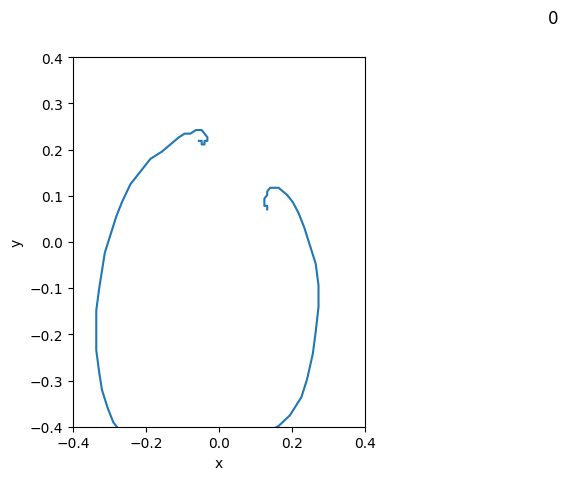

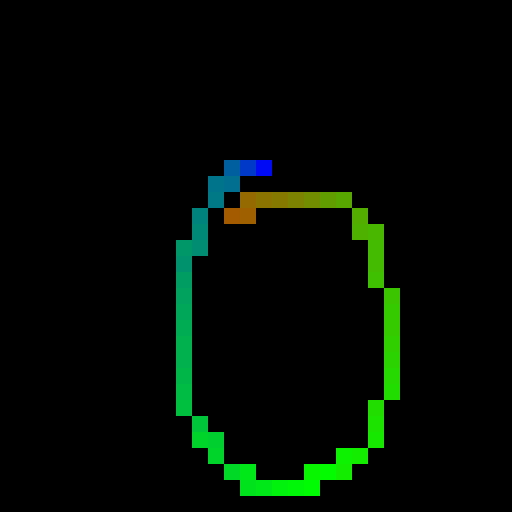

In [52]:
plot_stroke(strokes[4])
raster = rasterize_stroke(strokes[0]["strokePoints"], 0.5, 0.5, 32, 32)
PIL.Image.fromarray(raster).resize((512, 512), PIL.Image.NEAREST)

Finally, we'll generate a dataset in ```Keras```.

In [53]:
validation_ds = image_dataset_from_directory(
    directory=VAL_DIR,
    labels='inferred',
    label_mode='categorical',
    batch_size=32,
    image_size=(IMAGE_WIDTH, IMAGE_HEIGHT)).prefetch(buffer_size=32)

train_ds = image_dataset_from_directory(
    directory=TRAIN_DIR,
    labels='inferred',
    label_mode='categorical',
    batch_size=32,
    image_size=(IMAGE_WIDTH, IMAGE_HEIGHT)).prefetch(buffer_size=32)


test_ds = image_dataset_from_directory(
    directory=TEST_DIR,
    labels='inferred',
    label_mode='categorical',
    batch_size=32,
    image_size=(IMAGE_WIDTH, IMAGE_HEIGHT)).prefetch(buffer_size=32)

Found 9889 files belonging to 10 classes.
Found 19871 files belonging to 10 classes.
Found 3286 files belonging to 10 classes.


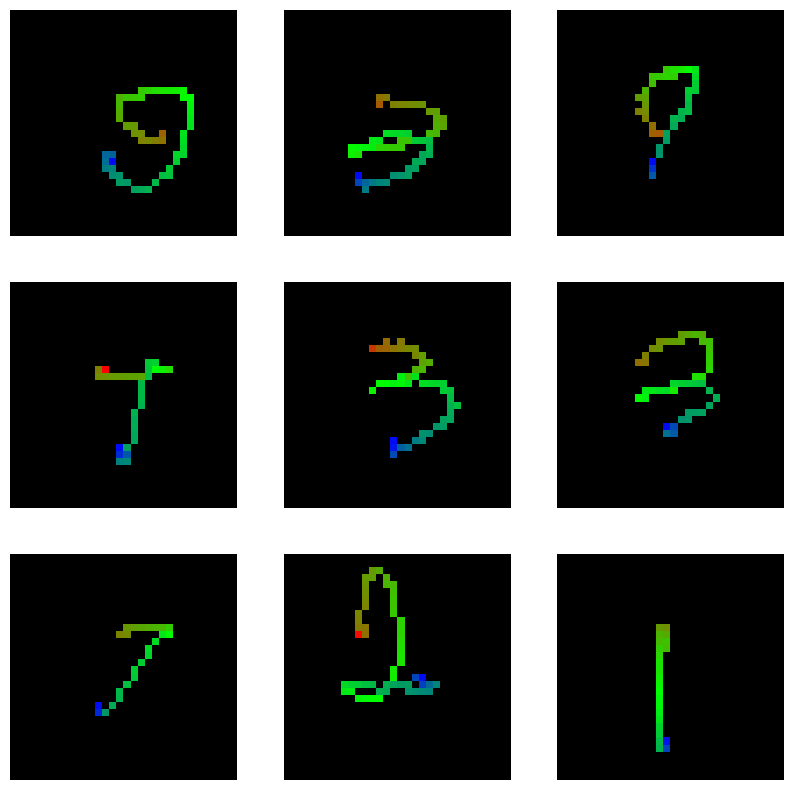

In [54]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.axis("off")

## Define your Model

ResNet

In [66]:
def residual_block(x, filters, stride=1):
    shortcut = x

    x = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, 3, strides=1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)

    return x

def create_resnet(input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 3), num_classes=NUM_GESTURES):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(64, 3, strides=1, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2, strides=2, padding='same')(x)

    x = residual_block(x, 64)
    x = residual_block(x, 64)
    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.6)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs, name='ResNet')

model_resnet = create_resnet()
model_resnet.summary()

Model: "ResNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_207 (Conv2D) │ (None, 32, 32,    │      1,728 │ input_layer_14[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_207[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_109      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_20    │ (None, 16, 16,    │          0 │ activation_109[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_208 (Conv2D) │ (None, 16, 16,    │     36,864 │ max_pooling2d_20… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_208[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_110      │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_209 (Conv2D) │ (None, 16, 16,    │     36,864 │ activation_110[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_209[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_59 (Add)        │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d_20… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_111      │ (None, 16, 16,    │          0 │ add_59[0][0]      │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_210 (Conv2D) │ (None, 16, 16,    │     36,864 │ activation_111[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_210[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_112      │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_211 (Conv2D) │ (None, 16, 16,    │     36,864 │ activation_112[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_211[0][0]

 Total params: 712,906 (2.72 MB)

 Trainable params: 710,986 (2.71 MB)

 Non-trainable params: 1,920 (7.50 KB)

Yolo

In [60]:
def create_yolo_style(input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 3), num_classes=NUM_GESTURES):
    def conv_block(x, filters):
        half = filters // 2
        x1 = layers.Conv2D(half, 3, padding='same', use_bias=False)(x)
        x2 = layers.Conv2D(half, 5, padding='same', use_bias=False)(x)
        x  = layers.Concatenate()([x1, x2])
        x  = layers.BatchNormalization()(x)
        x  = layers.LeakyReLU(negative_slope=0.1)(x)
        return x

    def channel_attention(x, ratio=4):
        c  = int(x.shape[-1])
        se = layers.GlobalAveragePooling2D()(x)
        se = layers.Reshape((1, 1, c))(se)
        se = layers.Conv2D(max(1, c // ratio), 1, activation='swish')(se)
        se = layers.Conv2D(c, 1, activation='sigmoid')(se)
        return layers.Multiply()([x, se])

    inputs = layers.Input(shape=input_shape)

    x = conv_block(inputs, 32)
    x = layers.MaxPooling2D(2, 2)(x)

    x = conv_block(x, 64)
    x = layers.MaxPooling2D(2, 2)(x)

    x = conv_block(x, 128)
    x = layers.MaxPooling2D(2, 2)(x)

    x = conv_block(x, 256)
    x = layers.MaxPooling2D(2, 2)(x)

    x = conv_block(x, 512)
    x = channel_attention(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs, name='YOLO_Style')

model_yolo = create_yolo_style()
model_yolo.summary()

Model: "YOLO_Style"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_138 (Conv2D) │ (None, 32, 32,    │        432 │ input_layer_10[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_139 (Conv2D) │ (None, 32, 32,    │      1,200 │ input_layer_10[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 32, 32,    │          0 │ conv2d_138[0][0], │
│ (Concatenate)       │ 32)               │            │ conv2d_139[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ concatenate_5[0]… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 16, 16,    │          0 │ leaky_re_lu_6[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_140 (Conv2D) │ (None, 16, 16,    │      9,216 │ max_pooling2d_12… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_141 (Conv2D) │ (None, 16, 16,    │     25,600 │ max_pooling2d_12… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 16, 16,    │          0 │ conv2d_140[0][0], │
│ (Concatenate)       │ 64)               │            │ conv2d_141[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ concatenate_6[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 8, 8, 64)  │          0 │ leaky_re_lu_7[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_142 (Conv2D) │ (None, 8, 8, 64)  │     36,864 │ max_pooling2d_13… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_143 (Conv2D) │ (None, 8, 8, 64)  │    102,400 │ max_pooling2d_13… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 8, 8, 128) │          0 │ conv2d_142[0][0], │
│ (Concatenate)       │                   │            │ conv2d_143[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 128) │        512 │ concatenate_7[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 3,364,458 (12.83 MB)

 Trainable params: 3,362,474 (12.83 MB)

 Non-trainable params: 1,984 (7.75 KB)

MobileViT

In [61]:

def mobile_vit_block(x, expansion=4, transformer_dim=16, num_transformer_blocks=2, num_heads=4):
    shortcut = x
    in_channels = int(x.shape[-1])

    x = layers.Conv2D(expansion * in_channels, 1, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)

    x = layers.DepthwiseConv2D(3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)

    x = layers.Conv2D(transformer_dim, 1, use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    h = int(x.shape[1])
    w = int(x.shape[2])
    c = int(x.shape[3])

    x = layers.Reshape((h * w, c))(x)

    for _ in range(num_transformer_blocks):
        x1 = layers.LayerNormalization(epsilon=1e-6)(x)
        attn = layers.MultiHeadAttention(
            num_heads=min(num_heads, max(1, c // 4)),
            key_dim=max(1, c // max(1, min(num_heads, max(1, c // 4))))
        )(x1, x1)
        x = layers.Add()([x, attn])

        x2 = layers.LayerNormalization(epsilon=1e-6)(x)
        mlp = layers.Dense(c * 2, activation='swish')(x2)
        mlp = layers.Dense(c)(mlp)
        x = layers.Add()([x, mlp])

    x = layers.Reshape((h, w, c))(x)

    x = layers.Conv2D(in_channels, 1, use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Add()([x, shortcut])
    return x

def create_mobilevit(input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 3), num_classes=NUM_GESTURES):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(16, 3, strides=2, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)

    x = mobile_vit_block(x, expansion=2, transformer_dim=16, num_transformer_blocks=1)
    x = layers.MaxPooling2D(2, 2)(x)

    x = mobile_vit_block(x, expansion=4, transformer_dim=24, num_transformer_blocks=2)
    x = layers.MaxPooling2D(2, 2)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='swish')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs, name='MobileViT')

model_mobilevit = create_mobilevit()
model_mobilevit.summary()


Model: "MobileViT"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_150 (Conv2D) │ (None, 16, 16,    │        432 │ input_layer_11[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │         64 │ conv2d_150[0][0]  │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_80       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_151 (Conv2D) │ (None, 16, 16,    │        512 │ activation_80[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        128 │ conv2d_151[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_81       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_25 │ (None, 16, 16,    │        288 │ activation_81[0]… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        128 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_82       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_152 (Conv2D) │ (None, 16, 16,    │        512 │ activation_82[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │         64 │ conv2d_152[0][0]  │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_20          │ (None, 256, 16)   │          0 │ batch_normalizat… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 16)   │         32 │ reshape_20[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 16)   │      1,088 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_39 (Add)        │ (None, 256, 16)   │          0 │ reshape_20[0][0], │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 16)   │         32 │ add_39[0][0]    

 Total params: 25,530 (99.73 KB)

 Trainable params: 24,970 (97.54 KB)

 Non-trainable params: 560 (2.19 KB)

EfficientNetV2

In [62]:
def mbconv_block(x, filters, expansion, stride):
    shortcut = x
    in_channels = int(x.shape[-1])

    x = layers.Conv2D(expansion * in_channels, 1, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)

    x = layers.DepthwiseConv2D(3, strides=stride, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)

    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Reshape((1, 1, expansion * in_channels))(se)
    se = layers.Conv2D(max(1, expansion * in_channels // 4), 1, activation='swish')(se)
    se = layers.Conv2D(expansion * in_channels, 1, activation='sigmoid')(se)
    x = layers.Multiply()([x, se])

    x = layers.Conv2D(filters, 1, use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if stride == 1 and in_channels == filters:
        x = layers.Add()([x, shortcut])

    return x

def create_efficientnetv2(input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 3), num_classes=NUM_GESTURES):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, strides=2, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)

    x = mbconv_block(x, 16, 1, 1)
    x = mbconv_block(x, 24, 6, 2)
    x = mbconv_block(x, 24, 6, 1)
    x = mbconv_block(x, 48, 6, 2)
    x = mbconv_block(x, 48, 6, 1)
    x = mbconv_block(x, 64, 6, 2)
    x = mbconv_block(x, 64, 6, 1)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(320, activation='swish')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs, name='EfficientNetV2')

model_efficientnet = create_efficientnetv2()
model_efficientnet.summary()

Model: "EfficientNetV2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_157 (Conv2D) │ (None, 16, 16,    │        864 │ input_layer_12[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        128 │ conv2d_157[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_85       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_158 (Conv2D) │ (None, 16, 16,    │      1,024 │ activation_85[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        128 │ conv2d_158[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_86       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_27 │ (None, 16, 16,    │        288 │ activation_86[0]… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        128 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_87       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ activation_87[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_24          │ (None, 1, 1, 32)  │          0 │ global_average_p… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_159 (Conv2D) │ (None, 1, 1, 8)   │        264 │ reshape_24[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_160 (Conv2D) │ (None, 1, 1, 32)  │        288 │ conv2d_159[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_16         │ (None, 16, 16,    │          0 │ activation_87[0]… │
│ (Multiply)          │ 32)               │            │ conv2d_160[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_161 (Conv2D) │ (None, 16, 16,    │        512 │ multiply_16[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │         64 │ conv2d_161[0][0]  │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 365,506 (1.39 MB)

 Trainable params: 359,362 (1.37 MB)

 Non-trainable params: 6,144 (24.00 KB)

ConvNeXt

In [63]:

def convnext_block(x, filters):
    shortcut = x
    in_channels = int(x.shape[-1])

    x = layers.DepthwiseConv2D(7, padding='same', use_bias=False)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    x = layers.Conv2D(filters * 4, 1, use_bias=False)(x)
    x = layers.Activation('gelu')(x)

    def grn_fn(t):
        gx = keras.ops.mean(keras.ops.square(t), axis=(1, 2), keepdims=True)
        nx = keras.ops.sqrt(gx + 1e-6)
        return t / nx

    x = layers.Lambda(grn_fn)(x)

    x = layers.Conv2D(filters, 1, use_bias=False)(x)

    if in_channels != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same', use_bias=False)(shortcut)

    x = layers.Add()([x, shortcut])
    return x

def create_convnext(input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 3), num_classes=NUM_GESTURES):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(64, 4, strides=4, padding='same')(inputs)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    for _ in range(3):
        x = convnext_block(x, 64)
    x = layers.MaxPooling2D(2, 2, padding='same')(x)

    x = layers.Conv2D(128, 1, padding='same')(x)
    for _ in range(3):
        x = convnext_block(x, 128)
    x = layers.MaxPooling2D(2, 2, padding='same')(x)

    x = layers.Conv2D(256, 1, padding='same')(x)
    for _ in range(3):
        x = convnext_block(x, 256)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.Dense(256, activation='gelu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs, name='ConvNeXt')

model_convnext = create_convnext()
model_convnext.summary()


Model: "ConvNeXt"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_186 (Conv2D) │ (None, 8, 8, 64)  │      3,136 │ input_layer_13[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 8, 64)  │        128 │ conv2d_186[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_34 │ (None, 8, 8, 64)  │      3,136 │ layer_normalizat… │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 8, 64)  │        128 │ depthwise_conv2d… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_187 (Conv2D) │ (None, 8, 8, 256) │     16,384 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_100      │ (None, 8, 8, 256) │          0 │ conv2d_187[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_9 (Lambda)   │ (None, 8, 8, 256) │          0 │ activation_100[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_188 (Conv2D) │ (None, 8, 8, 64)  │     16,384 │ lambda_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_50 (Add)        │ (None, 8, 8, 64)  │          0 │ conv2d_188[0][0], │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_35 │ (None, 8, 8, 64)  │      3,136 │ add_50[0][0]      │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 8, 64)  │        128 │ depthwise_conv2d… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_189 (Conv2D) │ (None, 8, 8, 256) │     16,384 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_101      │ (None, 8, 8, 256) │          0 │ conv2d_189[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_10 (Lambda)  │ (None, 8, 8, 256) │          0 │ activation_101[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_190 (Conv2D) │ (None, 8, 8, 64)  │     16,384 │ lambda_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_51 (Add)        │ (None, 8, 8, 64)  │          0 │ conv2d_190[0][0], │
│                     │                   │            │ add_50[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_36 │ (None, 8, 8, 64)  │      3,136 │ add_51[0][0]      │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 8, 64)  │        128 │ depthwise_conv2d… │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 2,246,410 (8.57 MB)

 Trainable params: 2,246,410 (8.57 MB)

 Non-trainable params: 0 (0.00 B)

## Train your Model

Now that we have a preprocessed dataset and a model its time to train that model with that dataset!

In [64]:
EPOCHS = 40

checkpointFileLoc = CHKPT_DIR + "/save_at_{epoch:02d}.h5"

def train_model(model, model_name, validation_ds, train_ds, epochs=EPOCHS, batch_size=64, lr=0.001):
    print(f'\nTraining model{model_name}')

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy', keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')]
    )

    callbacks = [
        keras.callbacks.ReduceLROnPlateau('val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
        keras.callbacks.EarlyStopping('val_accuracy', patience=5, restore_best_weights=True, verbose=1),
        keras.callbacks.ModelCheckpoint(checkpointFileLoc, 'val_accuracy', save_best_only=True, verbose=0)
    ]

    start_time = time.time()
    history = model.fit(
        train_ds,
        validation_data=validation_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )
    train_time = time.time() - start_time

    test_results = model.evaluate(validation_ds, verbose=0)
    val_acc = test_results[1]
    num_samples = sum(x.shape[0] for x, _ in train_ds)
    samples_per_sec = num_samples / train_time if train_time > 0 else 0


    print(f'\n{model_name} Done')
    print(f' Training time: {train_time:.2f}s')
    print(f' Val acc: {val_acc*100:.2f}%')
    print(f' Params num: {model.count_params():,}')
    print(f' Throughput: {samples_per_sec:.1f} samples/s')

    return history, val_acc, train_time, samples_per_sec

In [65]:
models_config = [
    (model_resnet, 'ResNet'),
    (model_yolo, 'YOLO_Style'),
    (model_mobilevit, 'MobileViT'),
    (model_efficientnet, 'EfficientNetV2'),
    (model_convnext, 'ConvNeXt')
]

all_results = []
trained_models = {}

for model, name in models_config:
  history, val_acc, train_time, sps = train_model(
    model, name, validation_ds ,train_ds,
    epochs=EPOCHS
  )

  all_results.append({
      'name': name,
      'params': model.count_params(),
      'val_acc': val_acc,
      'train_time': train_time,
      'samples_per_sec': sps,
      'history': history
  })
  trained_models[name] = model



Training modelResNet
Epoch 1/40
621/621 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.8645 - loss: 0.4258 - precision: 0.9519 - recall: 0.7960

621/621 ━━━━━━━━━━━━━━━━━━━━ 321s 504ms/step - accuracy: 0.9595 - loss: 0.1358 - precision: 0.9878 - recall: 0.9392 - val_accuracy: 0.8939 - val_loss: 0.5284 - val_precision: 0.9011 - val_recall: 0.8906 - learning_rate: 0.0010
Epoch 2/40
621/621 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.9932 - loss: 0.0226 - precision: 0.9938 - recall: 0.9926

621/621 ━━━━━━━━━━━━━━━━━━━━ 334s 524ms/step - accuracy: 0.9949 - loss: 0.0175 - precision: 0.9954 - recall: 0.9945 - val_accuracy: 0.9873 - val_loss: 0.1599 - val_precision: 0.9873 - val_recall: 0.9873 - learning_rate: 0.0010
Epoch 3/40
621/621 ━━━━━━━━━━━━━━━━━━━━ 318s 512ms/step - accuracy: 0.9974 - loss: 0.0094 - precision: 0.9976 - recall: 0.9973 - val_accuracy: 0.9848 - val_loss: 0.1604 - val_precision: 0.9849 - val_recall: 0.9846 - learning_rate: 0.0010
Epoch 4/40
621/621 ━━━━━━━━━━━━━━━━━━━━ 325s 523ms/step - accuracy: 0.9979 - loss: 0.0073 - precision: 0.9980 - recall: 0.9978 - val_accuracy: 0.9839 - val_loss: 0.1940 - val_precision: 0.9840 - val_recall: 0.9837 - learning_rate: 0.0010
Epoch 5/40
621/621 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.9991 - loss: 0.0036 - precision: 0.9992 - recall: 0.9990
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
621/621 ━━━━━━━━━━━━━━━━━━━━ 351s 565ms/step - accuracy: 0.9977 - loss: 0.0084 - precision: 0.99

621/621 ━━━━━━━━━━━━━━━━━━━━ 317s 511ms/step - accuracy: 0.9996 - loss: 0.0017 - precision: 0.9996 - recall: 0.9996 - val_accuracy: 0.9874 - val_loss: 0.2284 - val_precision: 0.9875 - val_recall: 0.9873 - learning_rate: 5.0000e-04
Epoch 8/40
621/621 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.9999 - loss: 5.0856e-04 - precision: 0.9999 - recall: 0.9999
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
621/621 ━━━━━━━━━━━━━━━━━━━━ 326s 517ms/step - accuracy: 0.9997 - loss: 0.0014 - precision: 0.9997 - recall: 0.9997 - val_accuracy: 0.9868 - val_loss: 0.1618 - val_precision: 0.9868 - val_recall: 0.9868 - learning_rate: 5.0000e-04
Epoch 9/40
621/621 ━━━━━━━━━━━━━━━━━━━━ 315s 506ms/step - accuracy: 0.9997 - loss: 0.0013 - precision: 0.9997 - recall: 0.9997 - val_accuracy: 0.9874 - val_loss: 0.1920 - val_precision: 0.9874 - val_recall: 0.9874 - learning_rate: 2.5000e-04
Epoch 10/40
621/621 ━━━━━━━━━━━━━━━━━━━━ 305s 490ms/step - accuracy: 0.9999 - loss: 3.3271e

621/621 ━━━━━━━━━━━━━━━━━━━━ 446s 707ms/step - accuracy: 0.9676 - loss: 0.0987 - precision: 0.9821 - recall: 0.9579 - val_accuracy: 0.9511 - val_loss: 0.4299 - val_precision: 0.9517 - val_recall: 0.9502 - learning_rate: 0.0010
Epoch 2/40
621/621 ━━━━━━━━━━━━━━━━━━━━ 0s 635ms/step - accuracy: 0.9929 - loss: 0.0230 - precision: 0.9933 - recall: 0.9925

...

621/621 ━━━━━━━━━━━━━━━━━━━━ 255s 411ms/step - accuracy: 0.9999 - loss: 4.8816e-04 - precision: 0.9999 - recall: 0.9999 - val_accuracy: 0.9838 - val_loss: 0.2494 - val_precision: 0.9840 - val_recall: 0.9837 - learning_rate: 2.5000e-04
Epoch 10/40
621/621 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 1.0000 - loss: 7.9496e-05 - precision: 1.0000 - recall: 1.0000

621/621 ━━━━━━━━━━━━━━━━━━━━ 256s 411ms/step - accuracy: 1.0000 - loss: 7.4624e-05 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9839 - val_loss: 0.2614 - val_precision: 0.9840 - val_recall: 0.9839 - learning_rate: 2.5000e-04
Epoch 11/40
621/621 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.9992 - loss: 0.0034 - precision: 0.9992 - recall: 0.9992
Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


621/621 ━━━━━━━━━━━━━━━━━━━━ 260s 410ms/step - accuracy: 0.9996 - loss: 0.0015 - precision: 0.9996 - recall: 0.9996 - val_accuracy: 0.9842 - val_loss: 0.2661 - val_precision: 0.9843 - val_recall: 0.9842 - learning_rate: 2.5000e-04
Epoch 12/40
621/621 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.9999 - loss: 1.8122e-04 - precision: 0.9999 - recall: 0.9999

621/621 ━━━━━━━━━━━━━━━━━━━━ 254s 409ms/step - accuracy: 0.9999 - loss: 1.2362e-04 - precision: 0.9999 - recall: 0.9999 - val_accuracy: 0.9843 - val_loss: 0.2671 - val_precision: 0.9845 - val_recall: 0.9843 - learning_rate: 1.2500e-04
Epoch 13/40
621/621 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 1.0000 - loss: 3.1315e-05 - precision: 1.0000 - recall: 1.0000

621/621 ━━━━━━━━━━━━━━━━━━━━ 262s 409ms/step - accuracy: 1.0000 - loss: 2.9476e-05 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9845 - val_loss: 0.2690 - val_precision: 0.9847 - val_recall: 0.9845 - learning_rate: 1.2500e-04
Epoch 14/40
621/621 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 1.0000 - loss: 2.4143e-05 - precision: 1.0000 - recall: 1.0000
Epoch 14: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
621/621 ━━━━━━━━━━━━━━━━━━━━ 255s 410ms/step - accuracy: 1.0000 - loss: 2.3904e-05 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9845 - val_loss: 0.2716 - val_precision: 0.9846 - val_recall: 0.9845 - learning_rate: 1.2500e-04
Epoch 15/40
621/621 ━━━━━━━━━━━━━━━━━━━━ 253s 408ms/step - accuracy: 1.0000 - loss: 1.4566e-05 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9845 - val_loss: 0.2730 - val_precision: 0.9846 - val_recall: 0.9845 - learning_rate: 6.2500e-05
Epoch 16/40
621/621 ━━━━━━━━━━━━━━━━━━━━ 254s 410ms/step - accuracy: 1.0000 -

Accuracy vs Model Size Trade-off
and Final Validation Accuracy by Architecture

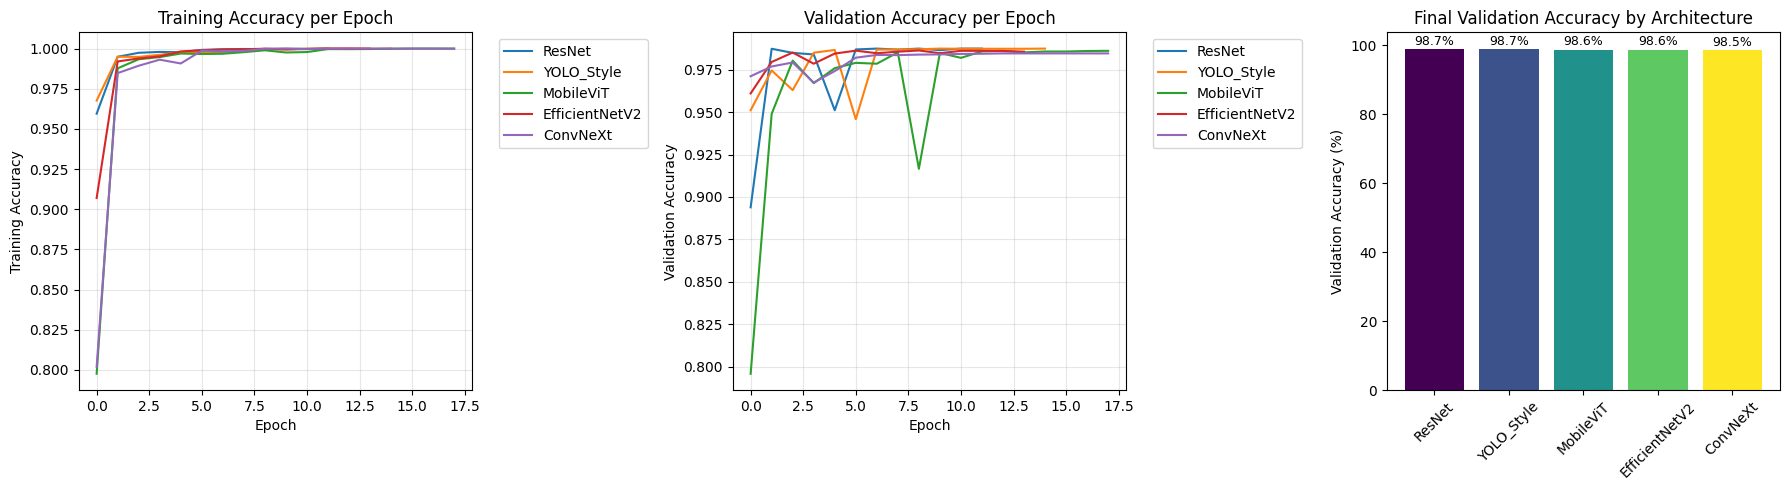

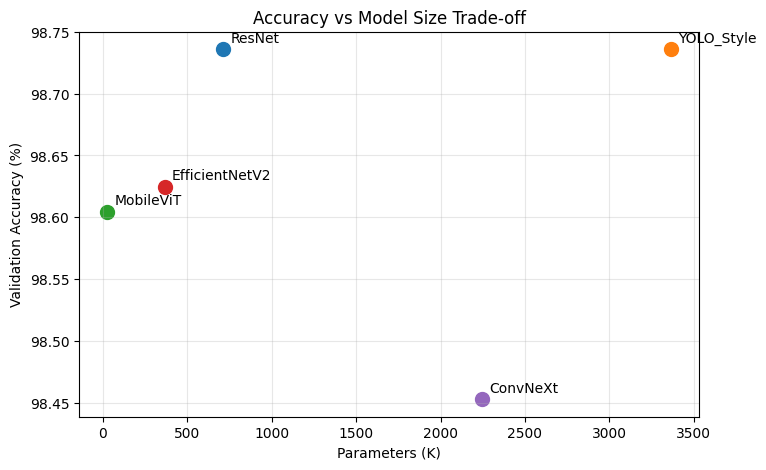

In [67]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
for r in all_results:
    plt.plot(r['history'].history['accuracy'], label=r['name'])
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.title('Training Accuracy per Epoch')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
for r in all_results:
    plt.plot(r['history'].history['val_accuracy'], label=r['name'])
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy per Epoch')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
names = [r['name'] for r in all_results]
accs = [r['val_acc'] * 100 for r in all_results]
colors = plt.cm.viridis(np.linspace(0, 1, len(names)))
bars = plt.bar(names, accs, color=colors)
plt.ylabel('Validation Accuracy (%)')
plt.title('Final Validation Accuracy by Architecture')
plt.xticks(rotation=45)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{acc:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('architecture_comparison.png', dpi=150, bbox_inches='tight')

plt.figure(figsize=(8, 5))
for r in all_results:
    plt.scatter(r['params']/1e3, r['val_acc']*100, s=100)
    plt.annotate(r['name'], (r['params']/1e3, r['val_acc']*100),
                 textcoords="offset points", xytext=(5, 5))
plt.xlabel('Parameters (K)')
plt.ylabel('Validation Accuracy (%)')
plt.title('Accuracy vs Model Size Trade-off')
plt.grid(True, alpha=0.3)
plt.savefig('accuracy_vs_size.png', dpi=150)
plt.show()

In [68]:
header = f'{"Architecture":<16} {"Params":>12} {"Val Acc":>10} {"Train Time":>12} {"Samples/s":>12}'
print('Architecture Comparison Summary')
print('=' * 64)
print(header)
print('-' * 64)

for r in all_results:
  print(f'{r["name"]:<16} {r["params"]:>12,} {r["val_acc"]*100:>9.2f}%'f' {r["train_time"]:>11.2f}s {r["samples_per_sec"]:>12.1f}')

print('='*64)

best_acc = max(all_results, key=lambda x: x['val_acc'])
fastest = min(all_results, key=lambda x: x['train_time'])
smallest = min(all_results, key=lambda x: x['params'])

print(f'\nHighest acc {best_acc["name"]} ({best_acc["val_acc"]*100:.2f}%)')
print(f'Fastest Train：{fastest["name"]} ({fastest["train_time"]:.2f}s)')
print(f'Fewest params：{smallest["name"]} ({smallest["params"]:,} params)')

Architecture Comparison Summary
Architecture           Params    Val Acc   Train Time    Samples/s
----------------------------------------------------------------
ResNet                712,906     98.74%     3913.83s          5.1
YOLO_Style          3,364,458     98.74%     6489.46s          3.1
MobileViT              25,530     98.60%     3655.08s          5.4
EfficientNetV2        365,506     98.62%     1541.58s         12.9
ConvNeXt            2,246,410     98.45%     4633.59s          4.3

Highest acc ResNet (98.74%)
Fastest Train：EfficientNetV2 (1541.58s)
Fewest params：MobileViT (25,530 params)


## Model Selection Justification

The model selected for TFLite conversion and Arduino deployment is
**EfficientNetV2**, based on the following analysis of the comparison table.

### Accuracy is effectively equal across all models

All five architectures achieved validation accuracy between 98.45% and 98.74%,
a difference of less than 0.3 percentage points. At this scale, the gap is
within normal variance and cannot justify selecting a heavier model purely
on accuracy grounds. The deployment constraints therefore become the
deciding factor.

### Flash memory eliminates three candidates

The Arduino Nano 33 BLE Sense provides 1 MB of Flash for model storage.
Under INT8 quantization, model size in bytes is approximately equal to
parameter count.
YOLO_Style and ConvNeXt are immediately eliminated — their quantized sizes
exceed the Flash limit by 3× and 2× respectively, making on-device
deployment impossible regardless of accuracy.

MobileViT fits in Flash but contains MultiHeadAttention operations that
are not fully supported by the TFLite INT8 runtime. Conversion either
fails or falls back to a slow reference kernel, making reliable real-time
inference on the microcontroller impossible.

ResNet fits within Flash but at 713 KB leaves very little headroom. Any
additional model metadata or quantization overhead risks exceeding the
limit on the actual device.

### EfficientNetV2 is best model

EfficientNetV2 achieves 98.62% validation accuracy while using only
365,506 parameters — less than half of ResNet's parameter count —
leaving a comfortable 634 KB of Flash headroom. Its architecture
consists entirely of standard Conv2D, DepthwiseConv2D, BatchNormalization,
and Squeeze-Excitation operations, all of which the TFLite INT8 kernel
supports natively without fallback. It also trained the fastest of all
five models at 1541 seconds with 12.9 samples per second, confirming
its computational efficiency.


In [97]:
best_model_name = "EfficientNetV2"
best_model = trained_models[best_model_name]
test_results = best_model.evaluate(test_ds)
test_loss = test_results[0]
test_acc = test_results[1]
print(f"best_model_name: {best_model_name}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


103/103 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.9903 - loss: 0.0306 - precision: 0.9909 - recall: 0.9903
best_model_name: EfficientNetV2
Test Loss: 0.0306
Test Accuracy: 0.9903


Confusion Matrix

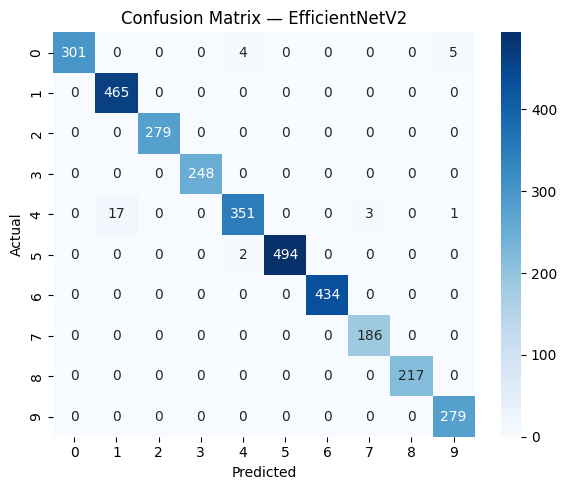

              precision    recall  f1-score   support

           0       1.00      0.97      0.99       310
           1       0.96      1.00      0.98       465
           2       1.00      1.00      1.00       279
           3       1.00      1.00      1.00       248
           4       0.98      0.94      0.96       372
           5       1.00      1.00      1.00       496
           6       1.00      1.00      1.00       434
           7       0.98      1.00      0.99       186
           8       1.00      1.00      1.00       217
           9       0.98      1.00      0.99       279

    accuracy                           0.99      3286
   macro avg       0.99      0.99      0.99      3286
weighted avg       0.99      0.99      0.99      3286

Weighted F1 Score: 0.9902


In [98]:
y_true, y_pred = [], []
for images, labels_batch in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels_batch.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(intToLabel.values()),
            yticklabels=list(intToLabel.values()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()


print(classification_report(y_true, y_pred,
                             target_names=list(intToLabel.values())))
f1 = f1_score(y_true, y_pred, average='weighted')
print(f'Weighted F1 Score: {f1:.4f}')

In [99]:
best_model.save(SAVED_MODEL_FILENAME)
print(f'Saved best model ({best_model_name}) to {SAVED_MODEL_FILENAME}')

Saved best model (EfficientNetV2) to models/magic_wand.keras


## Test your TensorFlow Model

Lets now test out the TF model on the test dataset. We'll print out any gesture we get wrong as well as the percentage of known gestures correct as well as the number of gestures that were marked as unknown.

Testing Gesture:  9  with datasize:  279
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━

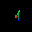

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
4 1 0.8569206
[4] expected, [1] found with score [0.856921]


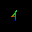

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━

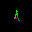

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━

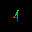

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━

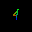

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
4 1 0.782706
[4] expected, [1] found with score [0.782706]


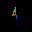

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━

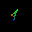

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
4 1 0.8753179
[4] expected, [1] found with score [0.875318]


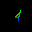

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
4 1 0.859623
[4] expected, [1] found with score [0.859623]


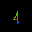

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
4 1 0.94561785
[4] expected, [1] found with score [0.945618]


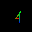

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
4 1 0.7790594
[4] expected, [1] found with score [0.779059]


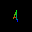

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━

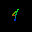

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
4 1 0.9723751
[4] expected, [1] found with score [0.972375]


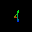

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
4 1 0.84856325
[4] expected, [1] found with score [0.848563]


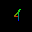

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
4 1 0.9068281
[4] expected, [1] found with score [0.906828]


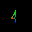

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
4 7 0.9998969
[4] expected, [7] found with score [0.999897]


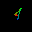

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Testing Gesture:  2  with datasize:  279
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━

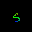

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━

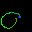

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━

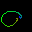

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━

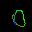

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
0 9 0.8262254
[0] expected, [9] found with score [0.826225]


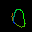

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━

In [100]:
SCORE_THRESHOLD = 0.75

def predict_image(model, filename):
  img = keras.preprocessing.image.load_img(filename, target_size=(IMAGE_WIDTH, IMAGE_HEIGHT))
  img_array = keras.preprocessing.image.img_to_array(img)
  img_array = tf.expand_dims(img_array, 0)
  predictions = model.predict(img_array).flatten()
  predicted_label_index = np.argmax(predictions)
  predicted_score = predictions[predicted_label_index]
  return (predicted_label_index, predicted_score)

correct_count = 0
wrong_count = 0
discarded_count = 0
for label_dir in glob.glob(TEST_DIR + "/*"):
  label = label_dir.replace(TEST_DIR + "/", "")
  print("Testing Gesture: ",label," with datasize: ",len(glob.glob(label_dir + "/*.png")))
  for filename in glob.glob(label_dir + "/*.png"):
    # TODO
    index, score = predict_image(best_model, filename)
    if score < SCORE_THRESHOLD:
      discarded_count += 1
      continue
    if index == labelToInt[label]:
      correct_count += 1
    else:
      wrong_count += 1
      print(label,index,score)
      print("[%s] expected, [%s] found with score [%f]" % (label, intToLabel[index], score))
      display(Image(filename=filename))

if correct_count + wrong_count == 0:
  print("All images marked as unknown!")
else:
  correct_percentage = (correct_count / (correct_count + wrong_count)) * 100
  print("%.1f%% correct (N=%d, %d unknown)" % (correct_percentage, (correct_count + wrong_count), discarded_count))

## Generate a TensorFlow Lite Model

Convert the frozen graph into a TensorFlow Lite model, which is fully quantized for use with embedded devices. The following cell will also print the model size.

In [101]:
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
model_no_quant_tflite = converter.convert()
open(FLOAT_TFL_MODEL_FILENAME, "wb").write(model_no_quant_tflite)


# def representative_dataset():
#   for filename in glob.glob(TEST_DIR + "/*/*.png"):
#     img = keras.preprocessing.image.load_img(filename, target_size=(IMAGE_WIDTH, IMAGE_HEIGHT))
#     img_array = keras.preprocessing.image.img_to_array(img)
#     img_array = tf.expand_dims(img_array, 0)  # Create batch axis for images, labels in train_ds.take(1):
#     yield([img_array])

def representative_dataset():
  for img_batch, _ in train_ds.take(100):
    for i in range(img_batch.shape[0]):
      sample = tf.expand_dims(img_batch[i], 0)
      yield [sample]
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
converter.representative_dataset = representative_dataset
model_tflite = converter.convert()

open(QUANTIZED_TFL_MODEL_FILENAME, "wb").write(model_tflite)

Saved artifact at '/tmp/tmpwy7vq8i6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor_648')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  135791113869776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135791113871312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135791113870352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135791113871504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135791113872272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135791113869008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135791113870544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135791113872080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135791113871696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135791113873040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13579111387

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


537608

Compare the sizes of the Tensorflow, TensorFlow Lite and Quantized TensorFlow Lite models.

In [102]:
def get_dir_size(dir):
  size = 0
  for f in os.scandir(dir):
    if f.is_file():
      size += f.stat().st_size
    elif f.is_dir():
      size += get_dir_size(f.path)
  return size

size_tf = os.path.getsize(SAVED_MODEL_FILENAME)
size_no_quant_tflite = os.path.getsize(FLOAT_TFL_MODEL_FILENAME)
size_tflite = os.path.getsize(QUANTIZED_TFL_MODEL_FILENAME)

pd.DataFrame.from_records(
    [["TensorFlow", f"{size_tf} bytes", ""],
     ["TensorFlow Lite", f"{size_no_quant_tflite} bytes ", f"(reduced by {size_tf - size_no_quant_tflite} bytes)"],
     ["TensorFlow Lite Quantized", f"{size_tflite} bytes", f"(reduced by {size_no_quant_tflite - size_tflite} bytes)"]],
     columns = ["Model", "Size", ""], index="Model")

,Size,
Model,,
TensorFlow,4769087 bytes,
TensorFlow Lite,1462500 bytes,(reduced by 3306587 bytes)
TensorFlow Lite Quantized,537608 bytes,(reduced by 924892 bytes)


## Test your TensorFlow Lite Models

Lets now test out the TFLite models (quantized and unquantized) on the test dataset. We'll print out any gesture we get wrong as well as the percentage of known gestures correct as well as the number of gestures that were marked as unknown.

In [104]:
def predict_tflite(tflite_model, filename):
  img = keras.preprocessing.image.load_img(filename, target_size=(IMAGE_WIDTH, IMAGE_HEIGHT))
  img_array = keras.preprocessing.image.img_to_array(img)
  img_array = tf.expand_dims(img_array, 0)

  interpreter = tf.lite.Interpreter(model_content=tflite_model)
  interpreter.allocate_tensors()

  input_details = interpreter.get_input_details()[0]
  output_details = interpreter.get_output_details()[0]

  input_scale, input_zero_point = input_details["quantization"]
  if (input_scale, input_zero_point) != (0.0, 0):
    img_array = np.multiply(img_array, 1.0 / input_scale) + input_zero_point
    img_array = img_array.astype(input_details["dtype"])

  interpreter.set_tensor(input_details["index"], img_array)
  interpreter.invoke()
  pred = interpreter.get_tensor(output_details["index"])[0]

  output_scale, output_zero_point = output_details["quantization"]
  if (output_scale, output_zero_point) != (0.0, 0):
    pred = pred.astype(np.float32)
    pred = np.multiply((pred - output_zero_point), output_scale)

  predicted_label_index = np.argmax(pred)
  predicted_score = pred[predicted_label_index]
  return (predicted_label_index, predicted_score)

In [105]:
def run_tflite_test(model_file):
  correct_count = 0
  wrong_count = 0
  discarded_count = 0
  for label_dir in glob.glob(TEST_DIR + "/*"):
    label = label_dir.replace(TEST_DIR + "/", "")
    print("Testing Gesture: ",label," with datasize: ",len(glob.glob(label_dir + "/*.png")))
    for filename in glob.glob(label_dir + "/*.png"):
      index, score = predict_tflite(model_file, filename)
      if score < SCORE_THRESHOLD:
        discarded_count += 1
        continue
      if index == labelToInt[label]:
        correct_count += 1
      else:
        wrong_count += 1
        print("[%s] expected, [%s] found with score [%f]" % (label, intToLabel[index], score))
        display(Image(filename=filename))

  total = correct_count + wrong_count
  if total == 0:
    print('All images discarded as unknown (score < %.2f).' % SCORE_THRESHOLD)
  else:
    print('%.1f%% correct (N=%d, %d unknown/discarded)' %
              (correct_count / total * 100, total, discarded_count))

First test the float model.

Testing Gesture:  9  with datasize:  279


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Testing Gesture:  3  with datasize:  248
Testing Gesture:  8  with datasize:  217
Testing Gesture:  4  with datasize:  372
[4] expected, [1] found with score [0.842767]


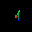

[4] expected, [1] found with score [0.856921]


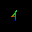

[4] expected, [1] found with score [0.900544]


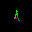

[4] expected, [1] found with score [0.998434]


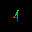

[4] expected, [1] found with score [0.817412]


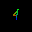

[4] expected, [1] found with score [0.782706]


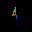

[4] expected, [7] found with score [0.908351]


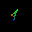

[4] expected, [1] found with score [0.875318]


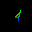

[4] expected, [1] found with score [0.859623]


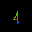

[4] expected, [1] found with score [0.945618]


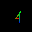

[4] expected, [1] found with score [0.779060]


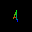

[4] expected, [7] found with score [0.825078]


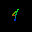

[4] expected, [1] found with score [0.972375]


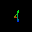

[4] expected, [1] found with score [0.848563]


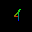

[4] expected, [1] found with score [0.906829]


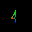

[4] expected, [7] found with score [0.999897]


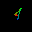

Testing Gesture:  2  with datasize:  279
Testing Gesture:  1  with datasize:  465
Testing Gesture:  5  with datasize:  496
[5] expected, [4] found with score [0.971145]


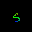

Testing Gesture:  7  with datasize:  186
Testing Gesture:  6  with datasize:  434
Testing Gesture:  0  with datasize:  310
[0] expected, [4] found with score [0.989588]


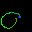

[0] expected, [4] found with score [0.956348]


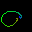

[0] expected, [9] found with score [0.907826]


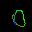

[0] expected, [9] found with score [0.826226]


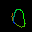

99.4% correct (N=3267, 19 unknown/discarded)


In [106]:
run_tflite_test(model_no_quant_tflite)

Then test the quantized model

Testing Gesture:  9  with datasize:  279
Testing Gesture:  3  with datasize:  248
Testing Gesture:  8  with datasize:  217
Testing Gesture:  4  with datasize:  372
[4] expected, [5] found with score [0.750000]


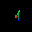

[4] expected, [5] found with score [0.980469]


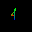

[4] expected, [1] found with score [0.757812]


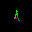

[4] expected, [1] found with score [0.996094]


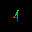

[4] expected, [1] found with score [0.781250]


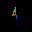

[4] expected, [7] found with score [0.976562]


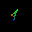

[4] expected, [1] found with score [0.871094]


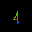

[4] expected, [1] found with score [0.773438]


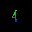

[4] expected, [1] found with score [0.960938]


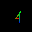

[4] expected, [1] found with score [0.863281]


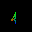

[4] expected, [1] found with score [0.882812]


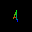

[4] expected, [7] found with score [0.984375]


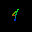

[4] expected, [7] found with score [0.972656]


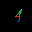

[4] expected, [1] found with score [0.929688]


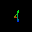

[4] expected, [1] found with score [0.804688]


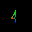

[4] expected, [9] found with score [0.906250]


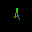

[4] expected, [7] found with score [0.996094]


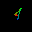

Testing Gesture:  2  with datasize:  279
Testing Gesture:  1  with datasize:  465
Testing Gesture:  5  with datasize:  496
[5] expected, [4] found with score [0.890625]


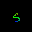

Testing Gesture:  7  with datasize:  186
Testing Gesture:  6  with datasize:  434
Testing Gesture:  0  with datasize:  310
[0] expected, [4] found with score [0.984375]


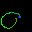

[0] expected, [4] found with score [0.925781]


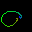

[0] expected, [9] found with score [0.753906]


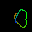

[0] expected, [9] found with score [0.871094]


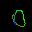

99.3% correct (N=3269, 17 unknown/discarded)


In [107]:
run_tflite_test(model_tflite)

In [ ]:
# TEST_IMAGE = # UPDATE ME e.g., "test/0/1.png"
# index, score = predict_tflite(model_no_quant_tflite, TEST_IMAGE)
# print("Float model result:")
# print(index, score) # prints the guessed index and the confidence
# index, score = predict_tflite(model_tflite, TEST_IMAGE)
# print("Quantized model result:")
# print(index, score) # prints the guessed index and the confidence

## Generate a TensorFlow Lite for Microcontrollers Model
To convert the TensorFlow Lite quantized model into a C source file that can be loaded by TensorFlow Lite for Microcontrollers on Arduino we simply need to use the ```xxd``` tool to convert the ```.tflite``` file into a ```.cc``` file.

In [108]:
# # Convert to a C source file, i.e, a TensorFlow Lite for Microcontrollers model
# !xxd -i {QUANTIZED_TFL_MODEL_FILENAME} > {TFL_CC_MODEL_FILENAME}
# # Update variable names
# REPLACE_TEXT = QUANTIZED_TFL_MODEL_FILENAME.replace('/', '_').replace('.', '_')
# !sed -i 's/'{REPLACE_TEXT}'/g_magic_wand_model_data/g' {TFL_CC_MODEL_FILENAME}

import subprocess

replace_text = QUANTIZED_TFL_MODEL_FILENAME.replace('/', '_').replace('.', '_')

result = subprocess.run(
  ['xxd', '-i', QUANTIZED_TFL_MODEL_FILENAME],
  capture_output=True, text=True
)
if result.returncode != 0:
  raise RuntimeError(f'xxd failed: {result.stderr}')

cc_content = result.stdout.replace(replace_text, 'g_magic_wand_model_data')

with open(TFL_CC_MODEL_FILENAME, 'w') as f:
  f.write(cc_content)

print(f'C array written to {TFL_CC_MODEL_FILENAME} ({len(cc_content):,} chars)')


C array written to models/magic_wand.cc (3,315,347 chars)


That's it! You've successfully converted your TensorFlow Lite model into a TensorFlow Lite for Microcontrollers model! Run the cell below to print out its contents which we'll need for our next step, deploying the model using the Arudino IDE!

In [109]:
# # Print the C source file
# !cat {TFL_CC_MODEL_FILENAME}
# # !tail {TFL_CC_MODEL_FILENAME} # run this command to just see the end of the file (aka the size)

with open(TFL_CC_MODEL_FILENAME, 'r') as f:
    cc_text = f.read()

preview_lines = cc_text.splitlines()[:40]
print('\n'.join(preview_lines))
print(f'... ({len(cc_text.splitlines())} lines total)')


unsigned char g_magic_wand_model_data[] = {
  0x1c, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x14, 0x00, 0x20, 0x00,
  0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00, 0x0c, 0x00, 0x00, 0x00,
  0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00,
  0x90, 0x00, 0x00, 0x00, 0x10, 0x01, 0x00, 0x00, 0x54, 0xb7, 0x05, 0x00,
  0x64, 0xb7, 0x05, 0x00, 0xcc, 0x32, 0x08, 0x00, 0x03, 0x00, 0x00, 0x00,
  0x01, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0x00, 0x12, 0x2c, 0xfa, 0xff,
  0x0c, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00, 0x3c, 0x00, 0x00, 0x00,
  0x0f, 0x00, 0x00, 0x00, 0x73, 0x65, 0x72, 0x76, 0x69, 0x6e, 0x67, 0x5f,
  0x64, 0x65, 0x66, 0x61, 0x75, 0x6c, 0x74, 0x00, 0x01, 0x00, 0x00, 0x00,
  0x04, 0x00, 0x00, 0x00, 0x64, 0xff, 0xff, 0xff, 0xdf, 0x00, 0x00, 0x00,
  0x04, 0x00, 0x00, 0x00, 0x08, 0x00, 0x00, 0x00, 0x6f, 0x75, 0x74, 0x70,
  0x75, 0x74, 0x5f, 0x30, 0x00, 0x00, 0x00, 0x00, 0x01, 0x00, 0x00, 0x00,
  0x04, 0x00, 0x00, 0x00, 0xc6, 0x2e, 0xfa, 0xff, 0x04, 0x00, 0x00, 

To download your model for use at a later date:

1. On the left of the UI click on the folder icon
2. Click on the three dots to the right of the ```.cc``` file you just generated and select "download." The file can be found at ```models/{TFL_CC_MODEL_FILENAME}``` which by default is ```models/magic_wand.cc```

Next we'll deploy that model using the Arduino IDE.